# Point Pattern

## Section 1: Data generation

### Loading packages.

In [1]:
import numpy as np
from dataclasses import dataclass
from typing import Tuple, List, Dict, Optional
import matplotlib.pyplot as plt

In [2]:
def GRF_gen_exp(nx, ny, L, length_scale, rng):
    """
    return a single realization of a Gaussian random field on our window [0,L]×[0,L], sampled on an ny×nx grid.
    
    Sample a mean 0, var 1 GRF on a periodic LxL domain with
    exponential correlation C(r) = exp(-r/l).

    circulant-embedding style using FFT of the spatial kernel.
    The field is periodic on the box, approximately stationary, and standardized.

    nx, ny: grid size in x/y
    L: physical side length (same units as length_scale).
    length_scale: the exponential correlation range l
    rng: NumPy Generator for reproducibility.
    """
    y = np.arange(ny) # [0, 1, 2, ..., ny-1], shape (ny,)
    x = np.arange(nx) # [0, 1, 2, ..., nx-1], shape (nx,)
    yy, xx = np.meshgrid(y, x, indexing='ij') 
    """
    e.g. ny=3, nx=4
    yy = [[0 0 0 0],
         [1 1 1 1],
         [2 2 2 2]]
    xx = [[0 1 2 3],
         [0 1 2 3],
         [0 1 2 3]]
    """
    # shortest wrap-around distance
    # Periodic means the right edge “touches” the left edge and top touches bottom, so correlation wraps around. for FFT trick
    # periodic. For a column with index k on a ring of length nx, the shortest steps from k to 0 are:
    # go left: distance k or wrap right across the boundary: distance nx - k. np.minimum(xx, nx - xx) picks the shorter path for each pixel.
    # k:         0 1 2 3 4 5 6 7
    # min(k,8-k):0 1 2 3 4 3 2 1
    dx_idx = np.minimum(xx, nx - xx)
    dy_idx = np.minimum(yy, ny - yy)
    dx = L / nx # pixel width in x (physical units)
    dy = L / ny # pixel width in y (physical units)
    # converts the wrapped index distances into a physical Euclidean distance at every grid cell
    R = np.sqrt((dx_idx * dx) ** 2 + (dy_idx * dy) ** 2) # 
    kernel = np.exp(-R / length_scale) # exponential covariance model

    # Power spectrum (nonnegative, real by symmetry)
    S = np.fft.rfft2(kernel)
    S = np.maximum(S.real, 0.0)

    # Complex white noise in rfft domain
    rng_c = rng.normal(size=S.shape) + 1j * rng.normal(size=S.shape)

    # Filter and invert
    F = np.sqrt(S) * rng_c
    field = np.fft.irfft2(F, s=kernel.shape)

    # Standardize
    field = field - field.mean()
    field = field / field.std()
    return field

In [ ]:
def GRF_gen_exp(nx, ny, L, length_scale, rng):
    y = np.arange(ny) 
    x = np.arange(nx) 
    yy, xx = np.meshgrid(y, x, indexing='ij') 
    dx_idx = np.minimum(xx, nx - xx)
    dy_idx = np.minimum(yy, ny - yy)
    dx = L / nx 
    dy = L / ny
    R = np.sqrt((dx_idx * dx) ** 2 + (dy_idx * dy) ** 2) # 
    kernel = np.exp(-R / length_scale)

    S = np.fft.rfft2(kernel)
    S = np.maximum(S.real, 0.0)

    rng_c = rng.normal(size=S.shape) + 1j * rng.normal(size=S.shape)

    F = np.sqrt(S) * rng_c
    field = np.fft.irfft2(F, s=kernel.shape)

    field = field - field.mean()
    field = field / field.std()
    return field

### Each location is N(0,1) tells our only the marginal distribution at a single point. The covariance function tells our how two or more locations relate. You draw several zero-mean, unit-variance fields (all N(0,1) marginally): The exponential covariance makes nearby pixels of each field similar; that, in turn, makes the intensities form spatial hotspots instead of pure noise. 

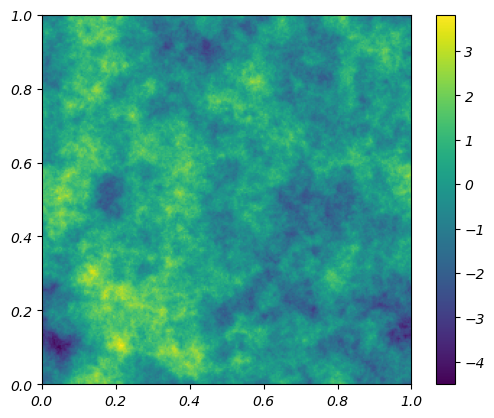

In [3]:
field_visual = GRF_gen_exp(256, 256, 1.0, 0.1, rng=np.random.default_rng(2025))
plt.imshow(field_visual, origin="lower", extent=[0,1,0,1])
plt.colorbar()
plt.show()

In [4]:
@dataclass # Dataclasses auto-generate __init__... Do not remove e.g. "int", "float" here.
class simulation_params:
    p: int                    = 4                         # number of types of points, it must match the lengths of phi, alpha, sigma, gamma0, gamma1.
    L: float                  = 1.0                       # window size (domain [0,L] x [0,L])
    nx: int                   = 256                       # grid resolution (x), pixel sizes are dx=L/nx, dy=L/ny. 
    ny: int                   = 256                       # grid resolution (y), Larger values = finer field & intensity maps.
    xi: float                 = 0.1                       # Length-scale for the shared Gaussian field Y.
    phi: Tuple[float, ...]    = (0.05, 0.05, 0.05, 0.05)  # Per-type length-scales for type-specific fields U_i.
    alpha: Tuple[float, ...]  = (0.5, -0.4, 0.6, -0.3)    # Coefficients for the shared field Y inside each type’s intensity.
    sigma: Tuple[float, ...]  = (np.sqrt(0.5), np.sqrt(0.5), np.sqrt(0.5), np.sqrt(0.5)) # Std devs of the type-specific field U_i, sigma_i^2 = 0.5
    gamma0: Tuple[float, ...] = (5.17, 5.44, 5.88, 6.13)  # Intercepts for log-intensity fixed component of each type
    gamma1: Tuple[float, ...] = (0.0, 0.3, -0.6, 0.6)     # Slopes for the covariate field z(u) in each type’s fixed component.
    background_coeff: float   = 0.5                       # lambda0(u) = exp(background_coeff*V(u)-*background_coeff^2/2), Sets a background lognormal field
    seed: Optional[int]       = 123                       # the seed number
    V_scale: float            = 0.05                      # scale parameter for V(u) field be set as 0.05
    z_scale: float            = 0.05                      # scale parameter for z(u) field be set as 0.05, chosen as an independent copy of V(u)

xxx

xxx

In [5]:
def simulate_point_pattern(params):
    # reading pre-defined parameters: 
    p = params.p
    L = params.L
    nx = params.nx
    ny = params.ny
    dx = L/nx # pixel length in x
    dy = L/ny # in y
    pixel_area = dx*dy
    rng = np.random.default_rng(params.seed)
    alpha = np.asarray(params.alpha)
    sigma = np.asarray(params.sigma)
    gamma0 = np.asarray(params.gamma0)
    gamma1 = np.asarray(params.gamma1)
    V_field_scale_para = params.V_scale
    z_field_scale_para = params.z_scale
    Y_filed_scale_para_xi = params.xi
    lambda0_coeff = params.background_coeff

    # Compute 4 Gaussian random fields: V(u), z(u), shared Y(u), types U_i (u)
    V = GRF_gen_exp(nx, ny, L, length_scale = V_field_scale_para, rng=rng)
    z = GRF_gen_exp(nx, ny, L, length_scale = z_field_scale_para, rng=rng)
    Y = GRF_gen_exp(nx, ny, L, length_scale = Y_filed_scale_para_xi, rng=rng)
    U_list = []
    for i in range(p):
        phi_i = params.phi[i]
        U_i = GRF_gen_exp(nx, ny, L, length_scale=phi_i, rng=rng)
        U_list.append(U_i)

    # Compute Baseline intensity function lambda0(u) and types intensities Lambda(u)_i:
    lambda0 = np.exp(lambda0_coeff*V - (lambda0_coeff**2)/2)
    Lambda_list = []
    for i in range(p):
        Lambda_i = lambda0*np.exp(gamma0[i] + gamma1[i]*z)*np.exp(alpha[i]*Y + sigma[i]*U_list[i] - (alpha[i]**2)/2 - (sigma[i]**2)/2)
        Lambda_list.append(Lambda_i)

    # Poisson sampling per pixel then jitter within pixel
    points_by_type = []
    labels = []
    for i in range(p):
        # Lambda_list[i] is a 2D shape (ny, nx) intensity values for all pixels for type i
        mean_counts = Lambda_list[i]*pixel_area # intensity × area = expected count, multiply the intensity at each pixel by the area of that pixel
        # For each pixel, draw the random number of points from a Poisson distribution with that expected count.
        # a Poisson point process conditional on the intensity field. For each pixel (x,y), draw a random number of points with mean_counts[x,y]
        counts = rng.poisson(mean_counts)  # 2D counts 

        
        n_type_i = int(counts.sum()) # total number of points of type i across the whole window.
        # row and column indices of occupied pixels:
        ys, xs = np.nonzero(counts) # returns the coordinates (x, y) of all pixels that have at least 1 point.
        reps = counts[ys, xs] # For each occupied pixel (ys[k], xs[k]), reps[k] tells our how many points are in that pixel.
        
        if n_type_i > 0:
            ys_exp = np.repeat(ys, reps)
            xs_exp = np.repeat(xs, reps)
            ux = rng.uniform(0.0, 1.0, size=n_type_i)
            uy = rng.uniform(0.0, 1.0, size=n_type_i)
            x_coords = (xs_exp + ux) * dx
            y_coords = (ys_exp + uy) * dy
            pts = np.column_stack([x_coords, y_coords])
        else:
            pts = np.empty((0, 2))
        points_by_type.append(pts)
        labels.extend([i + 1] * pts.shape[0])

    labels_arr = np.asarray(labels, dtype=int)

    
    return {
        'points_by_type': points_by_type,
        'labels': labels_arr,
        'Lambda_list': Lambda_list,
        'lambda_base': lambda0,
        'log_lambda_base': np.log(lambda0),
        'grid_meta': {'L': L, 'nx': nx, 'ny': ny, 'dx': dx, 'dy': dy},
        'fields': {'V': V, 'z': z, 'Y': Y, 'U_list': U_list},
        'params': params,
    }

In [6]:
def true_cross_pcf(r, alpha, sigma2, xi, phi, i, j):
    """
        g_ij(r) = exp( alpha_i*alpha_j*exp(-r/xi) + 1[i=j] * sigma_i^2 * exp(-r/phi_i) ).
    """
    r = np.asarray(r)
    common = np.exp(alpha[i]*alpha[j] * np.exp(-r / xi))
    if i == j:
        return common * np.exp(sigma2[i] * np.exp(-r / phi[i]))
    else:
        return common

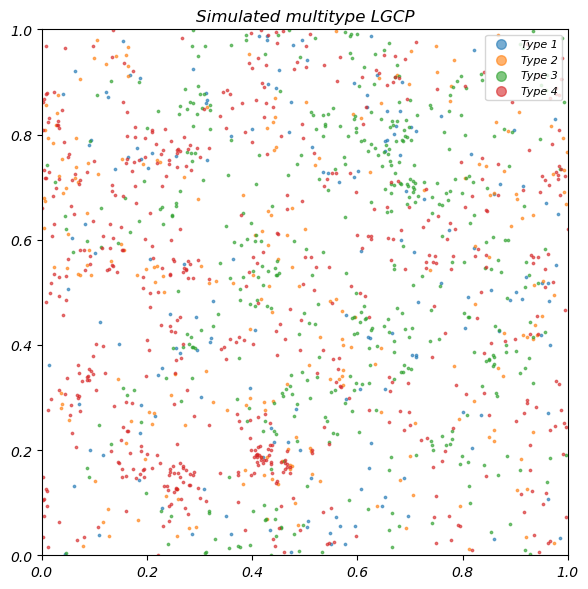

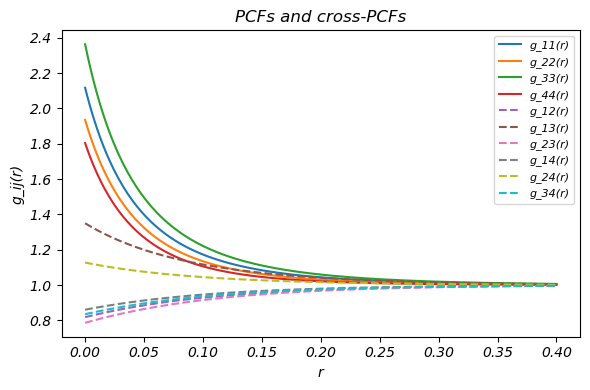

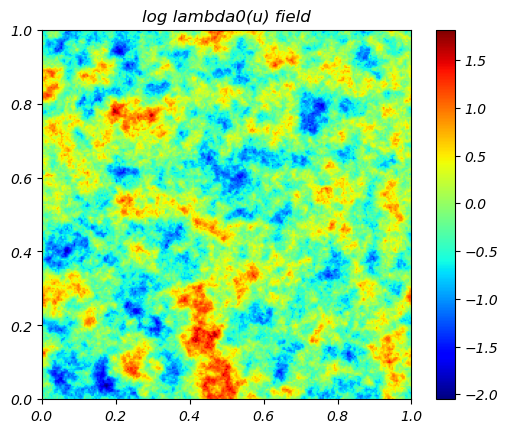

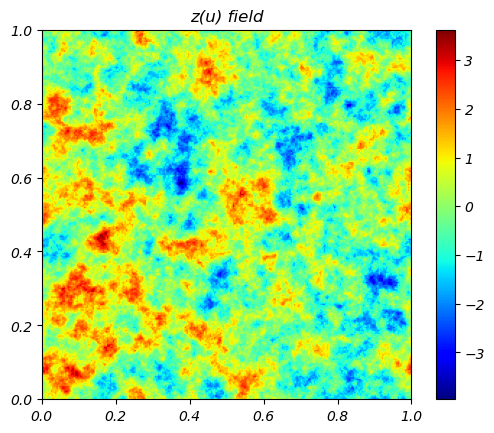

In [7]:
if __name__ == "__main__":

    params = simulation_params()
    sim = simulate_point_pattern(params)

    # Plot points by type
    plt.figure(figsize=(6, 6))
    colors = ["C0", "C1", "C2", "C3", "C4", "C5", "C6", "C7"]
    for i, pts in enumerate(sim['points_by_type']):
        if pts.size:
            plt.scatter(pts[:, 0], pts[:, 1], s=3, alpha=0.6,
                        label=f"Type {i+1}", color=colors[i % len(colors)])
    plt.xlim(0, params.L)
    plt.ylim(0, params.L)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.title("Simulated multitype LGCP")
    plt.legend(markerscale=4, fontsize=8, loc='upper right')
    plt.tight_layout()
    plt.show()

    # Plot theoretical cross PCFs 
    r = np.linspace(0, 0.4, 200)
    alpha = np.asarray(params.alpha)
    sigma2 = np.asarray(params.sigma)**2
    phi = np.asarray(params.phi)
    plt.figure(figsize=(6, 4))
    for i in range(params.p):
        gij = true_cross_pcf(r, alpha, sigma2, params.xi, phi, i, i)
        plt.plot(r, gij, label=f"g_{i+1}{i+1}(r)")
    if params.p >= 2:
        gij = true_cross_pcf(r, alpha, sigma2, params.xi, phi, 0, 1)
        plt.plot(r, gij, linestyle='--', label="g_12(r)")
    if params.p >= 3:
        gij = true_cross_pcf(r, alpha, sigma2, params.xi, phi, 0, 2)
        plt.plot(r, gij, linestyle='--', label="g_13(r)")
        gij = true_cross_pcf(r, alpha, sigma2, params.xi, phi, 1, 2)
        plt.plot(r, gij, linestyle='--', label="g_23(r)")
    if params.p >= 4:
        gij = true_cross_pcf(r, alpha, sigma2, params.xi, phi, 0, 3)
        plt.plot(r, gij, linestyle='--', label="g_14(r)")
        gij = true_cross_pcf(r, alpha, sigma2, params.xi, phi, 1, 3)
        plt.plot(r, gij, linestyle='--', label="g_24(r)")
        gij = true_cross_pcf(r, alpha, sigma2, params.xi, phi, 2, 3)
        plt.plot(r, gij, linestyle='--', label="g_34(r)")
    plt.xlabel("r")
    plt.ylabel("g_ij(r)")
    plt.title("PCFs and cross-PCFs")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    # 
    #plt.imshow(sim['fields']['V'], origin="lower", extent=[0,1,0,1], cmap="jet")
    #plt.title("V(u) field")
    #plt.colorbar()
    #plt.show()

    plt.imshow(sim['log_lambda_base'], origin="lower", extent=[0,1,0,1], cmap="jet")
    plt.title("log lambda0(u) field")
    plt.colorbar()
    plt.show()

    plt.imshow(sim['fields']['z'], origin="lower", extent=[0,1,0,1], cmap="jet")
    plt.title("z(u) field")
    plt.colorbar()
    plt.show()

    #plt.imshow(sim['fields']['Y'], origin="lower", extent=[0,1,0,1], cmap="jet")
    #plt.title("Y(u) field")
    #plt.colorbar()
    #plt.show()

In [ ]:
# ---------- Helpers ----------
def _bilinear_interp(grid: np.ndarray, pts: np.ndarray, L: float) -> np.ndarray:
    ny, nx = grid.shape
    dx = L / nx; dy = L / ny
    x = np.clip(pts[:, 0] / dx, 0, nx - 1 - 1e-9)
    y = np.clip(pts[:, 1] / dy, 0, ny - 1 - 1e-9)
    x0 = np.floor(x).astype(int); y0 = np.floor(y).astype(int)
    x1 = np.clip(x0 + 1, 0, nx - 1); y1 = np.clip(y0 + 1, 0, ny - 1)
    wx = x - x0; wy = y - y0
    f00 = grid[y0, x0]; f10 = grid[y0, x1]; f01 = grid[y1, x0]; f11 = grid[y1, x1]
    return (1 - wx) * (1 - wy) * f00 + wx * (1 - wy) * f10 + (1 - wx) * wy * f01 + wx * wy * f11

def _softmax_logits(beta: np.ndarray, X: np.ndarray) -> np.ndarray:
    N, q = X.shape
    K = beta.shape[0]
    logits = X @ beta.T                       # (N,K)
    m = np.max(logits, axis=1, keepdims=True)
    expK = np.exp(logits - m)
    denom = expK.sum(axis=1, keepdims=True) + np.exp(-m)  # baseline exp(0-m)
    Pk = expK / denom
    Pp = 1.0 / denom.squeeze()
    return np.column_stack([Pk, Pp])          # (N,K+1)

def _loglik(beta: np.ndarray, X: np.ndarray, y: np.ndarray) -> float:
    K = beta.shape[0]; p = K + 1
    logits = X @ beta.T                       # (N,K)
    m = np.max(logits, axis=1, keepdims=True)
    expK = np.exp(logits - m)
    denom = expK.sum(axis=1) + np.exp(-m).squeeze()  # add baseline
    ll = 0.0
    # contribution from labeled classes 0..K-1
    for i in range(K):
        mask = (y == i)
        if mask.any():
            ll += (X[mask] @ beta[i]).sum()
    # subtract log normalizers (includes baseline)
    ll -= np.log(denom).sum()
    return float(ll)

# ---------- Stable multinomial fit (baseline = last class) ----------
def fit_beta_multinomial(points_by_type, z_grid, L, max_iter=60, tol=1e-6,
                         ridge=1e-3, penalize_intercept=False, verbose=False):
    """
    Returns dict: {'beta',(p-1,2), 'P',(N,p), 'X',(N,2), 'y',(N,)}
    ridge: L2 penalty λ on β (0 disables). Default stabilizes in case of separation.
    """
    p = len(points_by_type)
    # Stack design & labels
    X_list, y_list = [], []
    for i, pts in enumerate(points_by_type):
        n = pts.shape[0]
        if n:
            z_vals = _bilinear_interp(z_grid, pts, L)
            X_list.append(np.column_stack([np.ones(n), z_vals]))
            y_list.append(np.full(n, i, dtype=int))
    if not X_list:
        raise ValueError("No points.")
    X = np.vstack(X_list).astype(float)  # (N,2)
    y = np.concatenate(y_list)

    N, q = X.shape
    K = p - 1
    beta = np.zeros((K, q), dtype=float)

    # penalty mask (don’t penalize intercept if chosen)
    pen_mask = np.ones((K, q), dtype=float)
    if not penalize_intercept:
        pen_mask[:, 0] = 0.0

    prev_ll = _loglik(beta, X, y)
    for it in range(max_iter):
        P = _softmax_logits(beta, X)  # (N,p)

        # Gradient g (K,q): sum_n X_n [1{y=i} - p_i(n)]  -  λ * β (masked)
        g = np.zeros((K, q), dtype=float)
        for i in range(K):
            yi = (y == i).astype(float)
            g[i] = X[yi == 1].sum(axis=0) - (X * P[:, i:i+1]).sum(axis=0)
        if ridge > 0:
            g -= ridge * (beta * pen_mask)

        # Hessian H ((K*q),(K*q)) for -∇^2ℓ  (i.e., Fisher information)
        H = np.zeros((K, q, K, q), dtype=float)
        for i in range(K):
            Pi = P[:, i]
            for j in range(K):
                w = Pi * ((1.0 if i == j else 0.0) - P[:, j])  # (N,)
                H[i, :, j, :] = X.T @ (X * w[:, None])
        H2 = H.reshape(K*q, K*q)
        if ridge > 0:
            H2 += ridge * np.diag(pen_mask.reshape(K*q))

        g2 = g.reshape(K*q)

        # Newton **ascent** step: beta_new = beta + (H^{-1} g)
        try:
            step = np.linalg.solve(H2, g2)
        except np.linalg.LinAlgError:
            step = np.linalg.lstsq(H2 + 1e-6*np.eye(K*q), g2, rcond=None)[0]

        # Backtracking line search
        t = 1.0
        base_ll = prev_ll
        while t > 1e-4:
            beta_try = beta + t * step.reshape(K, q)
            ll_try = _loglik(beta_try, X, y)
            # include penalty in objective for acceptance
            if ridge > 0:
                ll_try -= 0.5 * ridge * np.sum((beta_try * pen_mask) ** 2)
                base = base_ll - 0.5 * ridge * np.sum((beta * pen_mask) ** 2)
            else:
                base = base_ll
            if ll_try >= base:
                beta = beta_try
                prev_ll = _loglik(beta, X, y)  # store unpenalized for next loop
                break
            t *= 0.5

        if np.max(np.abs(t * step)) < tol:
            if verbose:
                print(f"Converged at iter {it}")
            break

    P = _softmax_logits(beta, X)
    return {"beta": beta, "P": P, "X": X, "y": y}


sim = simulate_point_pattern(params)
fit = fit_beta_multinomial(sim["points_by_type"], sim["fields"]["z"], L=params.L,
                           ridge=1e-3, penalize_intercept=False)
beta_hat = fit["beta"]
print("beta_hat:\n", beta_hat)



# ---------- Utility: stack points in the SAME order as fit_beta_multinomial -----

def stack_points_in_type_order(points_by_type):
    """Stack points by type 0..p-1 (baseline is last), same order as fit_beta_multinomial."""
    pts_list = []
    for pts in points_by_type:
        if pts.size:
            pts_list.append(pts)
    if not pts_list:
        return np.empty((0, 2)), np.empty((0,), dtype=int)
    points = np.vstack(pts_list)
    labels = np.concatenate([np.full(pts.shape[0], i, dtype=int)
                             for i, pts in enumerate(points_by_type)])
    return points, labels

# ---------- Sensitivity (empirical) S_hat --------------------------------------

def build_S_hat(X: np.ndarray, P: np.ndarray) -> np.ndarray:
    """
    Empirical sensitivity matrix \hat S (blocks S_ij):
      S_ij = sum_n x_n x_n^T [ p_i(n)(1{ i=j } - p_j(n)) ],  i,j = 0..K-1
    Returns a (K*q, K*q) array, with K = p-1 and q = X.shape[1].
    """
    N, q = X.shape
    p = P.shape[1]
    K = p - 1
    S = np.zeros((K, q, K, q), dtype=float)
    for i in range(K):
        Pi = P[:, i]
        for j in range(K):
            if i == j:
                w = Pi * (1.0 - Pi)
            else:
                w = -Pi * P[:, j]
            S[i, :, j, :] = X.T @ (X * w[:, None])
    return S.reshape(K * q, K * q)

# ---------- Neighbor pairs within radius R (grid hashing) ----------------------

def _grid_hash(points: np.ndarray, L: float, cell: float):
    nx = max(1, int(np.ceil(L / cell)))
    ny = nx
    ix = np.clip((points[:, 0] / L * nx).astype(int), 0, nx - 1)
    iy = np.clip((points[:, 1] / L * ny).astype(int), 0, ny - 1)
    buckets = {}
    for idx in range(points.shape[0]):
        key = (ix[idx], iy[idx]); buckets.setdefault(key, []).append(idx)
    return buckets, nx, ny

def _pairs_within_R(points: np.ndarray, L: float, R: float):
    buckets, nx, ny = _grid_hash(points, L, R)
    pairs = []
    for (cx, cy), idxs in buckets.items():
        for dx in (-1, 0, 1):
            for dy in (-1, 0, 1):
                nxk = cx + dx; nyk = cy + dy
                if 0 <= nxk < nx and 0 <= nyk < ny:
                    jdxs = buckets.get((nxk, nyk), [])
                    for i in idxs:
                        for j in jdxs:
                            if j <= i:  # avoid duplicates/self
                                continue
                            if np.hypot(points[i, 0] - points[j, 0],
                                        points[i, 1] - points[j, 1]) <= R:
                                pairs.append((i, j))
    return pairs

# ---------- Omega_hat with TRUE g (for simulation study) -----------------------

def omega_hat_true(points_by_type, X, P, params: simulation_params, R: float) -> np.ndarray:
    """
    Build \hat Omega using the TRUE g_ij(r) (eq. 24) and the T_ij(u,v) term (eq. 12).
    Returns (K*q, K*q). Use only in simulations where truth is known.
    """
    # Stack points in same order as X/P were constructed (type-by-type)
    points, _ = stack_points_in_type_order(points_by_type)
    N, q = X.shape
    p = P.shape[1]
    K = p - 1

    S = build_S_hat(X, P)
    Omega = S.copy()

    pairs = _pairs_within_R(points, params.L, R)
    if not pairs:
        return Omega

    alpha = np.asarray(params.alpha)
    sigma2 = (np.asarray(params.sigma) ** 2)
    xi = params.xi
    phi = np.asarray(params.phi)

    def g_ij(r, i, j):
        common = np.exp(alpha[i] * alpha[j] * np.exp(-r / xi))
        return common * np.exp(sigma2[i] * np.exp(-r / phi[i])) if i == j else common

    add = np.zeros((K, q, K, q), dtype=float)

    for a, b in pairs:
        xa = X[a]; xb = X[b]
        Za = np.outer(xa, xb)  # (q,q)
        r = np.hypot(points[a, 0] - points[b, 0], points[a, 1] - points[b, 1])

        # g_pl(u,v) = sum_{l,l'} p_l(u) p_{l'}(v) g_{ll'}(r)
        gpl = 0.0
        for l in range(p):
            for l2 in range(p):
                gpl += P[a, l] * P[b, l2] * g_ij(r, l, l2)
        if gpl <= 0:
            continue  # numerical guard

        for i in range(K):
            g_il = np.array([g_ij(r, i, l) for l in range(p)])
            for j in range(K):
                gij = g_ij(r, i, j)
                g_jl = np.array([g_ij(r, j, l) for l in range(p)])
                # T_ij(u,v) = (1 + g_ij)/g_pl - ( sum_l p_l(v) g_{i l} + sum_l p_l(u) g_{j l} )/g_pl
                Tij = (1.0 + gij) / gpl - (P[b, :] @ g_il + P[a, :] @ g_jl) / gpl
                w = P[a, i] * P[b, j] * Tij
                add[i, :, j, :] += Za * w

    Omega += add.reshape(K * q, K * q)
    return Omega

# ---------- Sandwich variance & CIs --------------------------------------------

def sandwich_variance(beta_hat: np.ndarray, X: np.ndarray, P: np.ndarray,
                      points_by_type, params: simulation_params,
                      method: str = "poisson", R: float = 0.4,
                      z0: float = 0.5):
    """
    Compute Var(β̂) via sandwich S^{-1} Ω S^{-1}, with:
      - method='poisson': Ω = S
      - method='true'   : Ω from true g (simulation-only)
    Returns dict with V, se_beta, and CIs for β and θ_i(z0)=β_{i0}+β_{i1} z0.
    """
    K, q = beta_hat.shape
    S = build_S_hat(X, P)
    if method == "poisson":
        Omega = S.copy()
    elif method == "true":
        Omega = omega_hat_true(points_by_type, X, P, params, R)
    else:
        raise ValueError("method must be 'poisson' or 'true'")

    # Sandwich
    try:
        Sinv = np.linalg.inv(S)
    except np.linalg.LinAlgError:
        Sinv = np.linalg.pinv(S)
    V = Sinv @ Omega @ Sinv

    # SEs for β blocks
    se_beta = np.zeros_like(beta_hat)
    for i in range(K):
        blk = V[i*q:(i+1)*q, i*q:(i+1)*q]
        se_beta[i] = np.sqrt(np.diag(blk))

    # CIs
    z90, z95 = 1.6448536269514722, 1.959963984540054
    ci90_beta = np.stack([beta_hat - z90 * se_beta, beta_hat + z90 * se_beta])
    ci95_beta = np.stack([beta_hat - z95 * se_beta, beta_hat + z95 * se_beta])

    # Theta_i(z0) = β_{i0} + β_{i1} z0
    theta = beta_hat[:, 0] + beta_hat[:, 1] * z0
    se_theta = np.zeros(K)
    for i in range(K):
        gvec = np.zeros(K * q)
        gvec[i*q:(i+1)*q] = np.array([1.0, z0])
        se_theta[i] = np.sqrt(gvec @ V @ gvec)
    ci90_theta = np.stack([theta - z90 * se_theta, theta + z90 * se_theta])
    ci95_theta = np.stack([theta - z95 * se_theta, theta + z95 * se_theta])

    return dict(V=V, se_beta=se_beta,
                ci90_beta=ci90_beta, ci95_beta=ci95_beta,
                theta=theta, se_theta=se_theta,
                ci90_theta=ci90_theta, ci95_theta=ci95_theta)



# Simulate
sim = simulate_point_pattern(params)

# Fit β (baseline = last type)
fit = fit_beta_multinomial(sim["points_by_type"], sim["fields"]["z"], params.L)
beta_hat, X, P = fit["beta"], fit["X"], fit["P"]

# Poisson-working variance (naïve)
vc_pois = sandwich_variance(beta_hat, X, P, sim["points_by_type"], params,
                            method="poisson", R=0.4, z0=0.5)
print("SE_beta (poisson):\n", vc_pois["se_beta"])
print("95% CI for θ(z0):\n", vc_pois["ci95_theta"].T)

# “True” variance (uses known g_ij from the simulator — for coverage studies)
vc_true = sandwich_variance(beta_hat, X, P, sim["points_by_type"], params,
                            method="true", R=0.4, z0=0.5)
print("SE_beta (true-g):\n", vc_true["se_beta"])
print("95% CI for θ(z0):\n", vc_true["ci95_theta"].T)

beta_hat:
 [[-1.10942141 -0.42837262]
 [-0.83786116 -0.1204341 ]
 [-0.27302013 -1.15887305]]
SE_beta (poisson):
 [[0.09104703 0.09114633]
 [0.08447599 0.07820655]
 [0.07231411 0.07899468]]
95% CI for θ(z0):
 [[-1.5064869  -1.14072855]
 [-1.04978078 -0.74637563]
 [-1.02141834 -0.68349497]]
